# Mental Health in Tech
## 0. Overview

### Importing

In [480]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style("darkgrid")
import re

In [481]:
import sqlite3 as sql
database = 'database/mental_health.sqlite'
con = sql.connect(database)

## Overview of Database

In [482]:
answers = pd.read_sql('SELECT * FROM Answer', con)
survey = pd.read_sql('SELECT * FROM Survey', con)
questions = pd.read_sql('SELECT * FROM question', con)

print('Questions db shape: '+ str(questions.shape))
print('Answers db shape: '+ str(answers.shape))
print('Survey db shape: '+ str(survey.shape))

Questions db shape: (105, 2)
Answers db shape: (236898, 4)
Survey db shape: (5, 2)


We can surmise what the Question and Answer databases contain, what about the Survey table?

In [483]:
query = """SELECT * 
           FROM Survey"""

run_sql = pd.read_sql(query, con)
run_sql

,SurveyID,Description
0,2014,mental health survey for 2014
1,2016,mental health survey for 2016
2,2017,mental health survey for 2017
3,2018,mental health survey for 2018
4,2019,mental health survey for 2019


The **Survey** table contains labelling and IDs of the **year** conducted.

### Questions

In [484]:
query = """SELECT *
           FROM Question"""

run_sql = pd.read_sql(query, con)
run_sql

,questiontext,questionid
0,What is your age?,1
1,What is your gender?,2
2,What country do you live in?,3
3,"If you live in the United States, which state ...",4
4,Are you self-employed?,5
...,...,...
100,Do you think that team members/co-workers woul...,114
101,"If yes, what condition(s) have you been diagno...",115
102,"If maybe, what condition(s) do you believe you...",116
103,Which of the following best describes your wor...,117


There are over 100 questions amongst the surveys, and after careful deliberation, only a select few questions were filtered for the use of this notebook and research.

The specific areas of interest will be: 
1. Sociodemographical Data
2. Tech Roles
3. Mental Conditions among respondents
4. Prevalence Rates of Conditions 
    * Overall prevalence
    * Prevalence among different tech roles

And more specific **tech industry - mental health** chosen areas of interest:
1. Company Size effects on Mental Health Systems
2. Presence of Mental Health Benefits, Resources
3. Perceptions on the Tech Industry and Support for Mental Health

In [485]:
query = """
        WITH questions AS (
                SELECT SurveyID AS year,
                       COUNT(DISTINCT QuestionID) AS num_questions
                FROM Answer
                GROUP BY SurveyID
                ORDER BY SurveyID
        ), respondents AS (
                SELECT SurveyID AS year, 
                       COUNT(DISTINCT UserID) AS num_respondents
                FROM Answer
                WHERE QuestionID = 2
                GROUP BY SurveyID        
        ) SELECT 
                r.year,
                q.num_questions,
                r.num_respondents
        FROM respondents r
        JOIN questions q ON r.year = q.year
        ORDER BY r.year                
        """

df_survey = pd.read_sql_query(query, con)
df_survey

,year,num_questions,num_respondents
0,2014,26,1260
1,2016,60,1433
2,2017,76,756
3,2018,76,417
4,2019,76,352


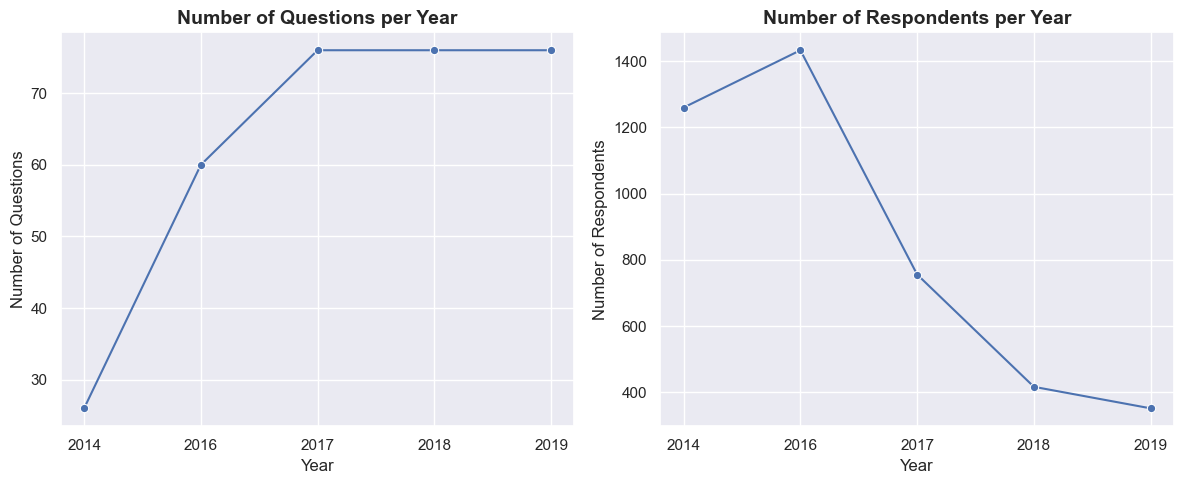

In [486]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.set_theme(style="whitegrid")

sns.lineplot(df_survey, x=df_survey['year'].astype(str), y='num_questions', ax=ax[0], marker='o')
ax[0].set_title('Number of Questions per Year', weight='bold', fontsize=14)
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Number of Questions")


sns.lineplot(df_survey, x=df_survey['year'].astype(str), y='num_respondents', ax=ax[1], marker='o')
ax[1].set_title('Number of Respondents per Year', weight='bold', fontsize=14)
ax[1].set_xlabel("Year")
ax[1].set_ylabel("Number of Respondents")

plt.tight_layout()
plt.show()

Over the years, the number of questions asked has considerably increased since 2014, and 76 questions became the standard since 2017.

Inversely, the number of respondents has a decreasing trend. Keep in mind that we are working with **smaller samples** in later years.

## 🌏 1. Sociodemographical Analysis

### 1.1 Age

#### 1.1.1 Distribution of All Ages

Text(0.5, 1.0, 'Age Distribution per Year')

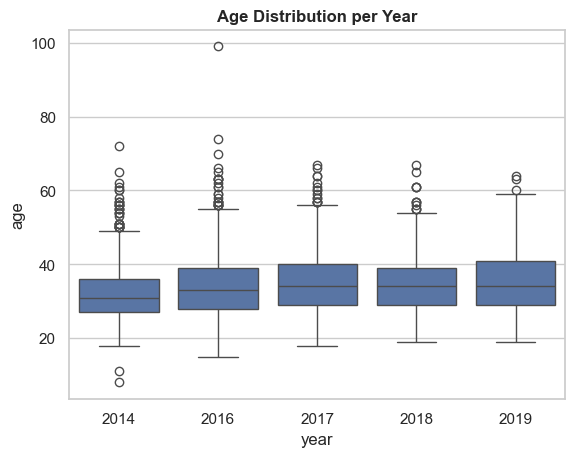

In [487]:
query = """SELECT SurveyID AS year,
                  CAST(AnswerText AS INTEGER) AS age
            FROM Answer
            WHERE QuestionID = 1
            AND CAST(AnswerText AS INTEGER) BETWEEN 6 AND 99
            ORDER BY SurveyID, age
        """

df_ages_all = pd.read_sql(query, con)

sns.boxplot(df_ages_all, x='year', y='age')
plt.title('Age Distribution per Year', weight='bold')

The mean age of respondents tends to be 30 and above. 

Curiously there are some outliers that need to be treated in the first 2014 survey, with such low ages that do not align with the supposed population of those working in the tech industry - supposedly adults.

#### 1.1.2 By **Age Group**

In [488]:
query = """WITH age_group AS(
            SELECT SurveyID AS year,
                CASE
                    WHEN CAST(AnswerText AS INTEGER) BETWEEN 18 AND 24 THEN '18-24'
                    WHEN CAST(AnswerText AS INTEGER) BETWEEN 25 AND 34 THEN '25-34'
                    WHEN CAST(AnswerText AS INTEGER) BETWEEN 35 AND 44 THEN '35-44'
                    WHEN CAST(AnswerText AS INTEGER) BETWEEN 45 AND 54 THEN '45-54'
                    WHEN CAST(AnswerText AS INTEGER) BETWEEN 55 AND 64 THEN '55-64'
                    WHEN CAST(AnswerText AS INTEGER) BETWEEN 65 AND 99 THEN '65+'
                END AS age_group,
                COUNT(*) AS count
            FROM Answer
            WHERE QuestionID = 1
                AND CAST(AnswerText AS INTEGER) BETWEEN 18 AND 99
            GROUP BY SurveyID, age_group
            )
        SELECT *
        FROM age_group
        """

df_ages = pd.read_sql(query, con)
df_ages = df_ages.pivot(index='year', columns='age_group', values='count').fillna(0)
df_ages = df_ages.astype(int)
df_ages.head()

age_group,18-24,25-34,35-44,45-54,55-64,65+
year,,,,,,
2014,156,707,321,51,15,2
2016,123,710,442,118,31,5
2017,60,339,256,81,16,2
2018,26,187,156,36,10,2
2019,29,147,114,50,11,0


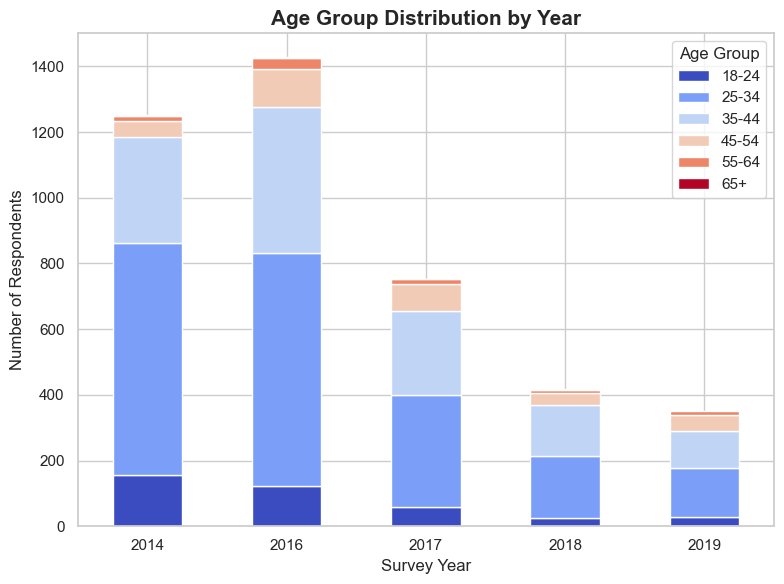

In [489]:
fig, ax = plt.subplots(figsize=(8, 6))

df_ages.plot(kind="bar", stacked=True, ax=ax, colormap='coolwarm')

ax.set_ylabel('Number of Respondents', size=12)
ax.set_xlabel('Survey Year', size=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.title('Age Group Distribution by Year', size=15, weight='bold')

labels_legend = df_ages.columns.tolist()  
ax.legend(labels=labels_legend, title="Age Group")

plt.tight_layout()
plt.show()

Majority of respondents fall within the age group of 25-34 and secondly 35-44. This is in line with the overarching focus on the tech industry and working adults.

### 1.2 Gender

In [490]:
query = """
        SELECT  SurveyID AS year, 
                AnswerText AS gender, 
                COUNT(*) AS count
        FROM Answer
        WHERE QuestionID = 2
        GROUP BY SurveyID, AnswerText
        ORDER BY SurveyID, count DESC"""

df_gender = pd.read_sql(query, con)
df_gender.head()

,year,gender,count
0,2014,Male,991
1,2014,Female,247
2,2014,Female (trans),2
3,2014,something kinda male?,1
4,2014,queer/she/they,1


This question allowed for open responses leading to data that needed to be cleaned:

#### Data Cleaning for gender category

In [491]:
def categorize_gender(text):
    if not isinstance(text, str):
        return "other"
    
    t = text.lower()

    female = ["female", "woman", "afab", "girl", "f", "fem", "mtf", "she", "her"]
    male = ["male", "man", "amab", "boy", "guy", "m", "masc", "ftm", "he","him"]

    if any(re.search(rf"\b{w}\b", t) for w in male):
        return "male"
    elif any(re.search(rf"\b{w}\b", t) for w in female):
        return "female"
    else:
        return "other"

In [492]:
df_gender['gender'] = df_gender['gender'].apply(categorize_gender)
df_gender = df_gender.groupby(['year', 'gender'])['count'].sum().reset_index()

df_gender['percent'] = (df_gender['count'] / df_gender.groupby('year')['count'].transform('sum') * 100).round(1)
df_gender.head()

,year,gender,count,percent
0,2014,female,252,20.0
1,2014,male,996,79.0
2,2014,other,12,1.0
3,2016,female,345,24.1
4,2016,male,1060,74.0


Text(0.5, 1.0, 'Gender Distribution per Year')

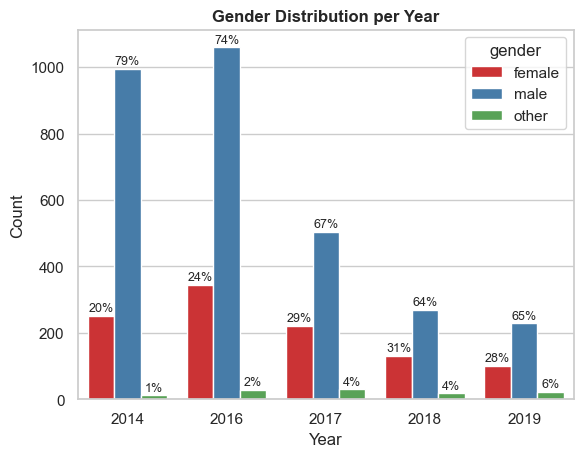

In [493]:
ax = sns.barplot(df_gender, x='year', y='count', hue='gender', errorbar=None, palette='Set1')

percent_labels = df_gender['percent'].round(0).astype(int).astype(str) + '%'

ax.bar_label(ax.containers[0], labels=percent_labels[df_gender['gender'] == 'female'].values, padding=1, fontsize=9)
ax.bar_label(ax.containers[1], labels=percent_labels[df_gender['gender'] == 'male'].values, padding=1, fontsize=9)
ax.bar_label(ax.containers[2], labels=percent_labels[df_gender['gender'] == 'other'].values, padding=1, fontsize=9)

plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Gender Distribution per Year', weight='bold')

Predominantly the survey population is male - with up to 64% to almost 80% per year being male

### 1.3 Country Demographics

In [494]:
query = """
        SELECT  SurveyID AS year, 
                AnswerText AS country, 
                COUNT(*) AS count
        FROM Answer
        WHERE QuestionID = 3
        GROUP BY SurveyID, AnswerText
        ORDER BY SurveyID, count DESC
        """

df_country = pd.read_sql(query, con)
df_country['country'] = df_country['country'].replace({'United States': 'United States of America'})
df_country.head()

,year,country,count
0,2014,United States of America,751
1,2014,United Kingdom,185
2,2014,Canada,72
3,2014,Germany,45
4,2014,Netherlands,27


In [495]:
select_years = [2017, 2018, 2019]

top10_countries = (df_country[df_country['year'].isin(select_years)]
                   .groupby('year')
                   .head(10)
)

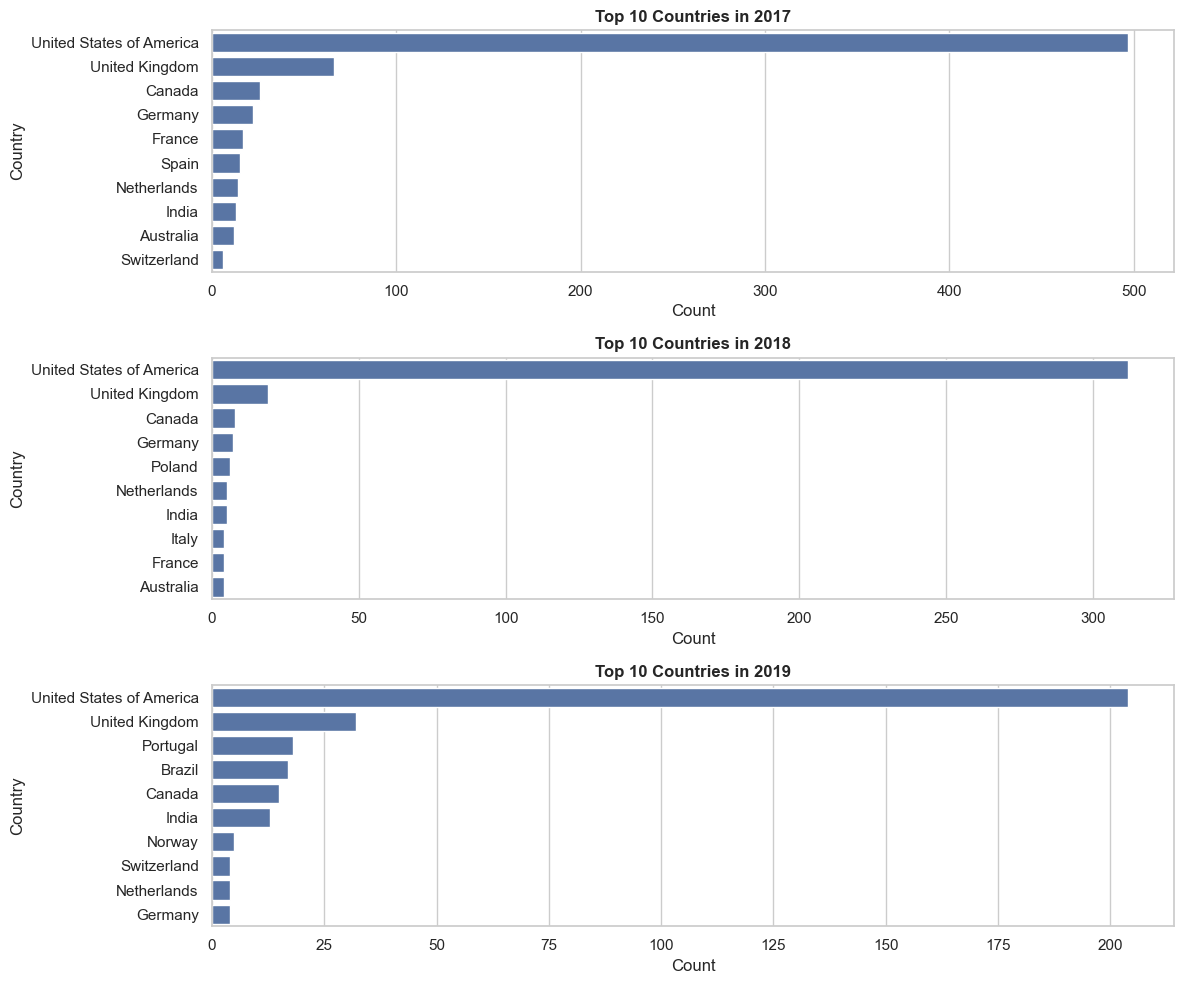

In [496]:
fig, axes = plt.subplots(3,1, figsize=(12,10))

for i, year in enumerate(select_years):
    subset = top10_countries[top10_countries['year'] == year]
    sns.barplot(data=subset, x='count', y='country', ax=axes[i])
    axes[i].set_title(f'Top 10 Countries in {year}', weight='bold')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('Country')

plt.tight_layout()
plt.show()

### 1.4 Race Demographics

Note: This question was only gathered in 2017 onwards.

In [497]:
query = """WITH Race AS (
            SELECT 
                SurveyID AS year, 
                CASE
                    WHEN AnswerText IN ('-1', 'I prefer not to answer') THEN 'N/A'
                    WHEN AnswerText IN ('White Hispanic', 'European American', 'More than one of the above') THEN 'Mixed'
                    ELSE AnswerText
                END AS race
            FROM Answer
            WHERE QuestionID = 89
        )
            SELECT year, race, COUNT(*) AS count
            FROM Race
            GROUP BY year, race
            ORDER BY year, count DESC"""

df_race = pd.read_sql(query, con)
df_race.head()

,year,race,count
0,2017,White,435
1,2017,N/A,288
2,2017,Mixed,14
3,2017,Asian,13
4,2017,Black or African American,6


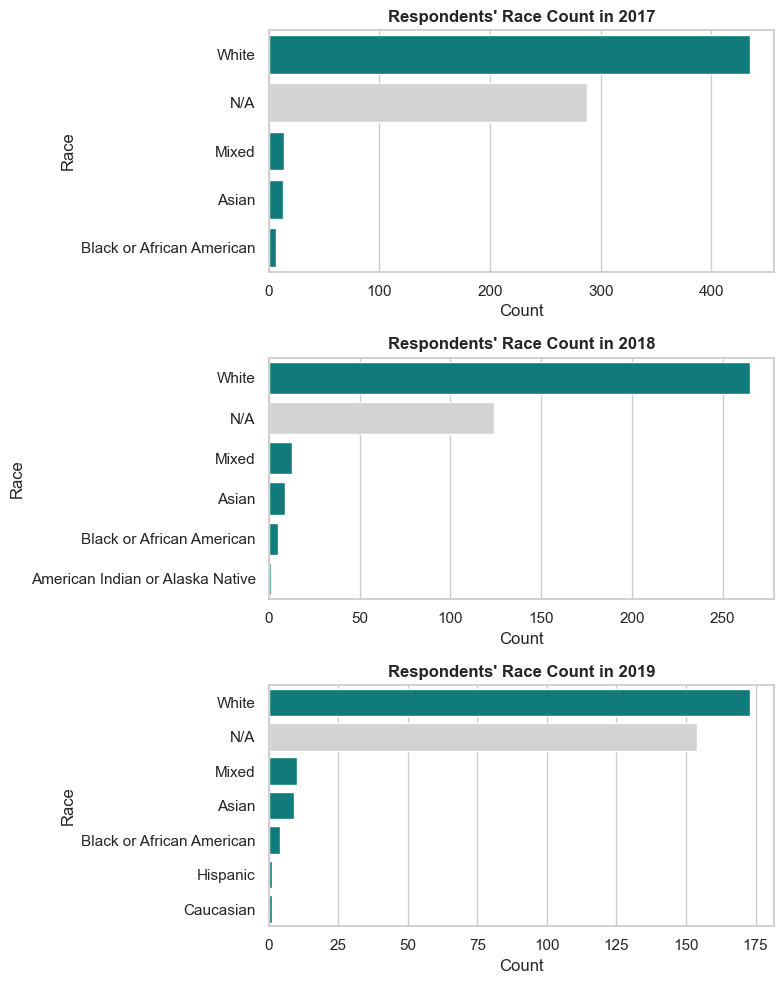

In [519]:
years = df_race['year'].unique()
years.sort()

fig, axes = plt.subplots(len(years), 1, figsize=(8, 10))

for i, year in enumerate(years):
    subset = df_race[df_race['year'] == year]
    colors = ['darkcyan' if j != 1 else 'lightgray' for j in range(len(subset))]
    sns.barplot(data=subset, x='count', y='race', hue='race', ax=axes[i], palette=colors)
    axes[i].set_title(f"Respondents' Race Count in {year}", weight='bold')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('Race')

plt.tight_layout()
plt.show()

Interestingly enough, a large percent chose not to answer this question

### ⚠️ Population Metrics and **Biases**

It is important to note that this dataset is unrepresentative and has biases with heavy counts leaning towards a specific population in terms of gender, race, and location. Respondents are predominantly male, white, and American. It is worth noting this bias as the dataset is not representative of a diverse population.

## 2. Mental Health in Tech

### 2.1 Proportion of Tech : Non-Tech participants

- (#9) Is your employer primarily a tech company/organization?

In [499]:
query = """
        SELECT SurveyID AS year, AnswerText AS tech_company, COUNT(AnswerText) AS count
        FROM Answer
        WHERE QuestionID = 9 AND AnswerText != -1
        GROUP BY year, AnswerText
        """

df = pd.read_sql(query, con)

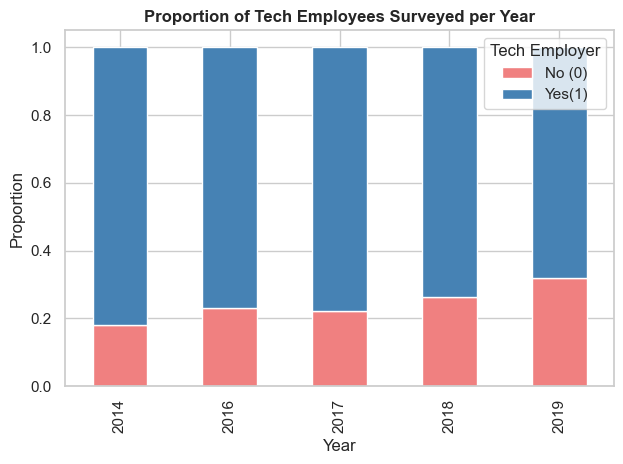

In [500]:
df['prop'] = df['count'] / df.groupby('year')['count'].transform('sum')

df_pivot = df.pivot(index='year', columns='tech_company', values='prop').fillna(0)

sns.set_theme(style="whitegrid")

df_pivot.plot(kind='bar', stacked=True, color=['lightcoral', 'steelblue'])

plt.title('Proportion of Tech Employees Surveyed per Year', weight='bold')
plt.xlabel('Year')
plt.ylabel('Proportion')
plt.legend(title='Tech Employer', labels=['No (0)', 'Yes(1)'])
plt.tight_layout()
plt.show()

### 2.2 Roles of Respondents
* (#117) Which of the following best describes your work position?

*Note: Data for this question is only available for **2016***

In [501]:
query = """
        SELECT AnswerText AS role, COUNT(AnswerText) AS count
        FROM Answer 
        WHERE QuestionID = 117
        GROUP BY AnswerText;
        """

df_roles = pd.read_sql(query, con)
df_roles = df_roles.sort_values("count", ascending=False)

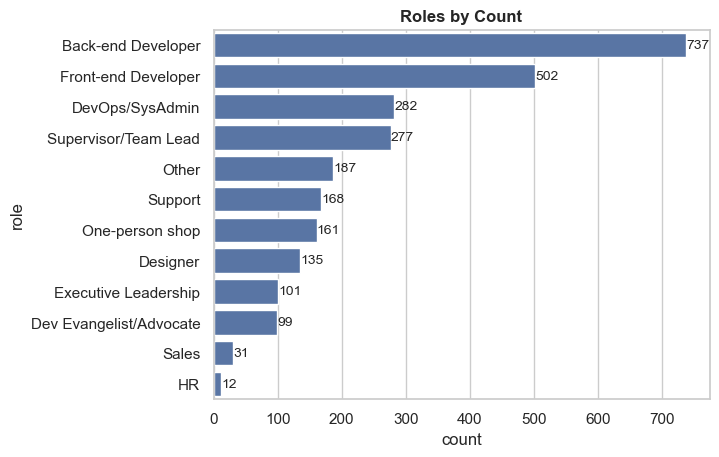

In [502]:
ax = sns.barplot(df_roles, x='count', y='role')
plt.title('Roles by Count', weight='bold')
ax.bar_label(ax.containers[0], fontsize = 10);

### 2.3 Diagnosis Counts & Prevalence Rates

Questions in use in this section:

- **(#115) If yes, what condition(s) have you been diagnosed with? (2072 total responses (multi-select allowed))**

#### 2.3.1 Diagnosis Count

In [503]:
query = """
        SELECT  AnswerText AS condition,
                COUNT(DISTINCT UserID) AS count
        FROM Answer 
        WHERE QuestionID = 115
        GROUP BY AnswerText
        ORDER BY count DESC;
        """

df_conditions_all = pd.read_sql(query, con)
df_conditions_all.head()

,condition,count
0,-1,865
1,"Mood Disorder (Depression, Bipolar Disorder, etc)",412
2,"Anxiety Disorder (Generalized, Social, Phobia,...",345
3,Attention Deficit Hyperactivity Disorder,121
4,Post-traumatic Stress Disorder,69


##### Categorizing Conditions

There are 12 fixed responses (and 1 "Other" choice) to choose from. To progress our analysis, I will be categorizing the free responses to one of the 12 fixed responses with regards to the source and in line with medical research as close as possible.

An additional category of conditions was made to consider those with Autism Spectrum Disorder (ASD)

There were 23 free responses that had to be categorized according to the dictionary below or fully dropped:

Terms were considered dropped if they are:
- not a condition that is mentally diagnosed (burn out)
- considered more of a physical condition than a mental / neurological psychiatric disorder (traumatic brain injury)
- not at all a mental condition / disorder (transgender)
- user stated they are not diagnosed

In [504]:
categories_dict = {
    "Mood Disorder (Depression, Bipolar Disorder, etc)": ["depression", "seasonal affective disorder"],
    "Anxiety Disorder (Generalized, Social, Phobia, etc)": ["anxiety"],
    "Attention Deficit Hyperactivity Disorder": ["add", "adhd"],
    "Post-traumatic Stress Disorder": ["ptsd"],
    "Obsessive-Compulsive Disorder": ["ocd"],
    "Substance Use Disorder": ["alcohol", "drug", "substance"],
    "Personality Disorder (Borderline, Antisocial, Paranoid, etc)": [],
    "Stress Response Syndromes": [],
    "Addictive Disorder": ["sexual addiction", "addiction"],
    "Eating Disorder (Anorexia, Bulimia, etc)": [],
    "Dissociative Disorder": ["depersonalization", "dissociative"],
    "Psychotic Disorder (Schizophrenia, Schizoaffective, etc)": ["schizo", "psychosis"],
    "Autism Spectrum Disorder (ASD)": ["autism", "asperges", "asperger", "pervasive", "pdd"]
}

def categorize_condition(text):
    if not isinstance(text, str) or not text.strip():
        return -1
    
    if text in categories_dict:
        return text

    text = text.lower().strip()

    drop_terms = [
        "transgender", "gender", "tinnitus", "traumatic brain injury", "sleeping disorder", "burn out", "burnout", "hurt", "haven't been formally diagnosed", "undiagnosed"
    ]
    if any(term in text for term in drop_terms):
        return -1
    
    for category, keywords in categories_dict.items():
        if any(keyword in text for keyword in keywords):
            return category
        
    return -1

In [505]:
df_conditions = df_conditions_all.copy()
df_conditions["condition"] = df_conditions_all["condition"].apply(categorize_condition)
df_conditions = df_conditions[df_conditions["condition"] != -1]

df_conditions = (df_conditions.groupby("condition", as_index=False)["count"]
                .sum()
                .sort_values(by=["count"], ascending=[False]))

df_conditions = df_conditions.reset_index(drop=True)
df_conditions.head()

,condition,count
0,"Mood Disorder (Depression, Bipolar Disorder, etc)",414
1,"Anxiety Disorder (Generalized, Social, Phobia,...",345
2,Attention Deficit Hyperactivity Disorder,124
3,Post-traumatic Stress Disorder,69
4,Obsessive-Compulsive Disorder,45


There are now **13 conditions / categories** of conditions

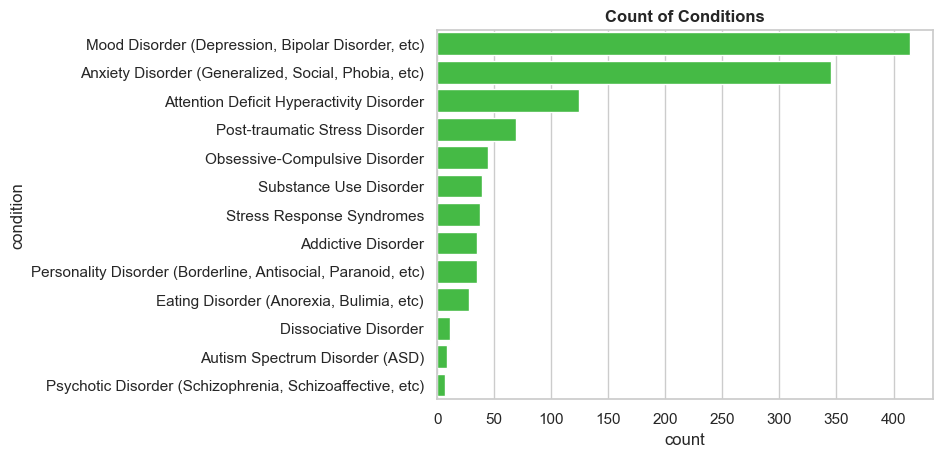

In [506]:
sns.barplot(df_conditions, x="count", y="condition", color='limegreen')

plt.title("Count of Conditions", weight='bold')
plt.show()

### 2.3.2 Overall Prevalence Rate of Different Conditions

Beyond specific counts and numbers, we will take a look at the prevalence rate of these 13 conditions. What proportion of the population is found to be affected by these conditions? The prevalence rate per individual disease is of focus.

The prevalence rate formula is given as: $$P = \frac{N}{T} * 100$$

Where: 

- Prevalence (proportion) (P) = Number of cases (N) ÷ Total number of people in the population (T) * 100
- n = 1,433 respondents in 2016




In [507]:
df_conditions['prevalence (%)'] = (((df_conditions['count']) / 1433) * 100)

#### Confidence Intervals

In [508]:
from statsmodels.stats.proportion import proportion_confint

n = 1433 

ci = df_conditions['count'].apply(lambda x: proportion_confint(count=x, nobs=n, alpha=0.05, method='wilson'))

df_conditions['ci_lower'] = [x[0] for x in ci]
df_conditions['ci_upper'] = [x[1] for x in ci]

df_conditions['ci_lower (%)'] = df_conditions['ci_lower'] * 100
df_conditions['ci_upper (%)'] = df_conditions['ci_upper'] * 100

df_conditions[['condition', 'prevalence (%)', 'ci_lower (%)', 'ci_upper (%)']]

,condition,prevalence (%),ci_lower (%),ci_upper (%)
0,"Mood Disorder (Depression, Bipolar Disorder, etc)",28.890440,26.602591,31.291163
1,"Anxiety Disorder (Generalized, Social, Phobia,...",24.075366,21.932933,26.356421
2,Attention Deficit Hyperactivity Disorder,8.653175,7.305810,10.221626
3,Post-traumatic Stress Disorder,4.815073,3.822352,6.049402
4,Obsessive-Compulsive Disorder,3.140265,2.355110,4.175983
5,Substance Use Disorder,2.721563,1.997202,3.698726
6,Stress Response Syndromes,2.651779,1.938016,3.618718
7,Addictive Disorder,2.442428,1.761361,3.377791
8,"Personality Disorder (Borderline, Antisocial, ...",2.442428,1.761361,3.377791
9,"Eating Disorder (Anorexia, Bulimia, etc)",1.953943,1.355287,2.809505


Text(0, 0.5, 'Condition')

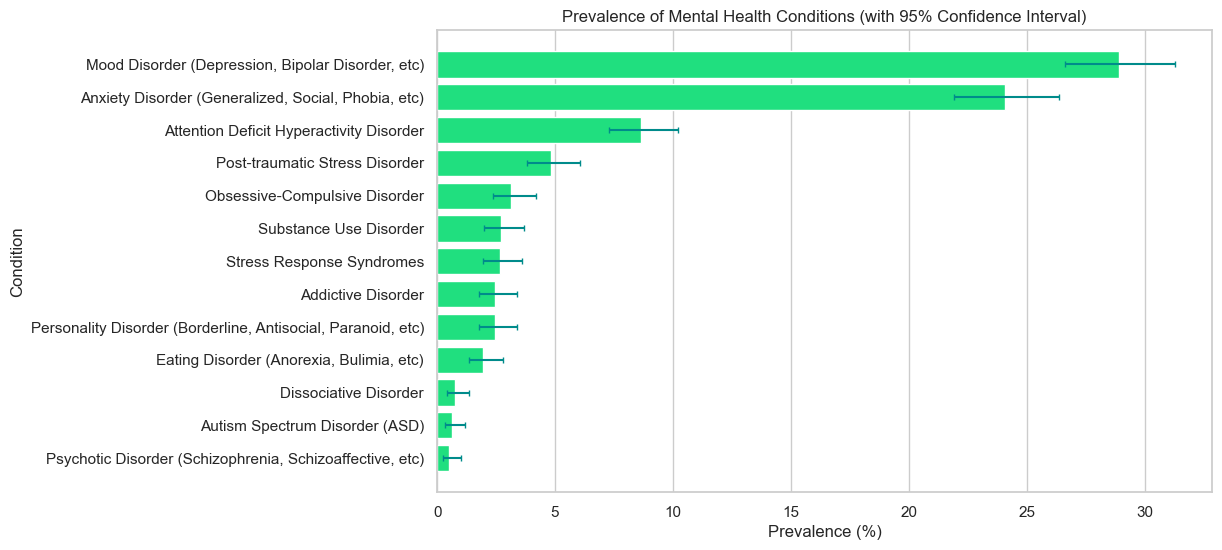

In [509]:
plt.figure(figsize=(10,6))
ax = sns.barplot(df_conditions, x='prevalence (%)', y='condition', color='springgreen')

plt.errorbar(
    x=df_conditions['prevalence (%)'],
    y=range(len(df_conditions)),
    xerr=[
        df_conditions['prevalence (%)'] - df_conditions['ci_lower (%)'],
        df_conditions['ci_upper (%)'] - df_conditions['prevalence (%)']
    ],
    fmt='none',        
    ecolor='darkcyan',
    capsize=2
)

plt.title('Prevalence of Mental Health Conditions (with 95% Confidence Interval)')
plt.xlabel('Prevalence (%)')
plt.ylabel('Condition')

### Prevalence Rates of Conditions in Different Roles in Tech

In [510]:
query = """
        WITH roles AS (
            SELECT 
                UserID,
                AnswerText AS role
            FROM Answer
            WHERE QuestionID = 117
        ), conditions AS (
            SELECT 
                UserID,
                AnswerText AS condition
            FROM Answer
            WHERE QuestionID = 115
        )
        SELECT
            r.UserID,
            r.role,
            c.condition
        FROM roles r
        LEFT JOIN conditions c
            ON c.UserID = r.UserID
        """

df_roles_conditions = pd.read_sql(query, con)
df_roles_conditions

,UserID,role,condition
0,1261,Back-end Developer,-1
1,1262,Back-end Developer,"Anxiety Disorder (Generalized, Social, Phobia,..."
2,1262,Back-end Developer,"Mood Disorder (Depression, Bipolar Disorder, etc)"
3,1262,Front-end Developer,"Anxiety Disorder (Generalized, Social, Phobia,..."
4,1262,Front-end Developer,"Mood Disorder (Depression, Bipolar Disorder, etc)"
...,...,...,...
3977,2692,DevOps/SysAdmin,Stress Response Syndromes
3978,2693,Other,"Anxiety Disorder (Generalized, Social, Phobia,..."
3979,2693,Other,"Eating Disorder (Anorexia, Bulimia, etc)"
3980,2693,Other,"Mood Disorder (Depression, Bipolar Disorder, etc)"


In [511]:
df_roles = df_roles_conditions.copy()
df_roles["condition"] = df_roles["condition"].apply(categorize_condition)
df_roles = df_roles[df_roles["condition"] != -1]

df_roles = (
    df_roles
    .drop_duplicates(subset=["UserID", "role", "condition"])
    .groupby(["role", "condition"], as_index=False)["UserID"]
    .nunique()
    .rename(columns={"UserID": "count"})
)

role_totals = (
    df_roles_conditions
    .drop_duplicates(subset=["UserID", "role"])
    .groupby("role", as_index=False)["UserID"]
    .nunique()
    .rename(columns={"UserID": "total"})
)

df_roles = df_roles.merge(role_totals, on="role", how="left")
df_roles["prevalence (%)"] = (df_roles["count"] / df_roles["total"] * 100).round(2)
df_roles = df_roles.sort_values(["role", "prevalence (%)"], ascending=[True, False]).reset_index(drop=True)

df_roles.head()


,role,condition,count,total,prevalence (%)
0,Back-end Developer,"Mood Disorder (Depression, Bipolar Disorder, etc)",196,737,26.59
1,Back-end Developer,"Anxiety Disorder (Generalized, Social, Phobia,...",168,737,22.80
2,Back-end Developer,Attention Deficit Hyperactivity Disorder,64,737,8.68
3,Back-end Developer,Post-traumatic Stress Disorder,30,737,4.07
4,Back-end Developer,Obsessive-Compulsive Disorder,17,737,2.31


In [512]:
df_roles_conditions['condition'] = df_roles_conditions['condition'].apply(categorize_condition)
df_roles_conditions = df_roles_conditions[df_roles_conditions['condition'] !=  -1]

In [513]:
print("No mental conditions: ", df_roles_conditions.isnull().sum())
print("Number of respondents with roles: ", df_roles_conditions.UserID.nunique())

No mental conditions:  UserID       0
role         0
condition    0
dtype: int64
Number of respondents with roles:  565


### 2.4 Company Size Factor
#### Impact and Correlations of **Company Size** to: Presence of **Mental Health Benefits, Resources, and Discussions** in the Workplace

- Company Size - (#8) How many employees does your company or organization have?
- Benefits - (#10) Does your employer provide mental health benefits as part of healthcare coverage?
- Formal Discussions on Mental Health - (#15) Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?
- Resources - (#16) Does your employer offer resources to learn more about mental health disorders and options for seeking help?

There are also questions of scaling: rating the importance of mental health placed by the company, and the individual's perception on how the tech industry handles mental health:
- Importance to the company - (#65) Overall, how much importance does your employer place on mental health? [0 - lowest to 10 highest]
- Perception on tech industry and mental support - (#85) Overall, how well do you think the tech industry supports employees with mental health issues? [1 - lowest to 5 highest]

For this section we are observing 2017 - 2019 responses where all questions above are present in the surveys. In lieue of this we will exclude 2014 and 2016.

The query that follows below is of considerable length but its usage simply **gathers the responses per question above**, with a **CTE per question**:

In [514]:
query = """
        WITH company_size AS (
                SELECT 
                        SurveyID AS year, 
                        UserID,
                        AnswerText AS company_size, 
                        CASE 
                                WHEN AnswerText = '1-5' THEN 1
                                WHEN AnswerText = '6-25' THEN 2
                                WHEN AnswerText = '26-100' THEN 3
                                WHEN AnswerText = '100-500' THEN 4
                                WHEN AnswerText = '500-1000' THEN 5
                                WHEN AnswerText = 'More than 1000' THEN 6
                        END AS size_num
                FROM Answer 
                WHERE QuestionID = 8 AND AnswerText != -1 
        ), benefits AS (
                SELECT 
                        SurveyID AS year,
                        UserID,
                        CASE
                                WHEN AnswerText = 'Yes' THEN 1
                                WHEN AnswerText = 'No' THEN 0
                        END AS mh_benefits
                FROM Answer
                WHERE QuestionID = 10
                        AND AnswerText IN ('Yes', 'No')
        ), discussions AS (
                SELECT 
                        SurveyID AS year,
                        UserID,
                        CASE
                                WHEN AnswerText = 'Yes' THEN 1
                                WHEN AnswerText = 'No' THEN 0
                        END AS mh_discussed
                FROM Answer
                WHERE QuestionID = 15
                        AND AnswerText IN ('Yes', 'No')
        ), resources AS (
                SELECT 
                        SurveyID AS year,
                        UserID,
                        CASE
                                WHEN AnswerText = 'Yes' THEN 1
                                WHEN AnswerText = 'No' THEN 0
                        END AS mh_resources
                FROM Answer
                WHERE QuestionID = 16
                        AND AnswerText IN ('Yes', 'No')
        ), importance AS (
                SELECT 
                        SurveyID AS year,
                        UserID,
                        CAST(AnswerText AS INTEGER) AS mh_importance
                FROM Answer
                WHERE QuestionID = 65
                        AND AnswerText != -1
        ), perception AS (
                SELECT 
                        SurveyID AS year,
                        UserID,
                        CAST(AnswerText AS INTEGER) AS industry_perception
                FROM Answer
                WHERE QuestionID = 85
                        AND AnswerText != -1
        ) SELECT
                c.UserID,
                c.year,
                c.company_size,
                c.size_num,
                b.mh_benefits,
                d.mh_discussed,
                r.mh_resources,
                i.mh_importance,
                p.industry_perception
        FROM company_size AS c
        JOIN benefits AS b 
                ON c.UserID = b.UserID AND c.year = b.year
        JOIN discussions AS d
                ON c.UserID = d.UserID AND c.year = d.year
        JOIN resources AS r
                ON c.UserID = r.UserID AND c.year = r.year
        JOIN importance AS i
                ON c.UserID = i.UserID AND c.year = i.year
        JOIN perception AS p
                ON c.UserID = p.UserID AND c.year = p.year
        WHERE c.year != 2014
        ORDER BY c.year
        """

df_tech = pd.read_sql(query, con)
df_tech.head()

,UserID,year,company_size,size_num,mh_benefits,mh_discussed,mh_resources,mh_importance,industry_perception
0,2695,2017,100-500,4,1,0,0,2,2
1,2700,2017,6-25,2,1,0,0,10,2
2,2701,2017,26-100,3,1,0,0,8,2
3,2704,2017,100-500,4,1,0,0,0,1
4,2706,2017,More than 1000,6,0,0,0,7,4


In [515]:
df_tech.company_size.value_counts()

company_size
More than 1000    215
100-500           172
26-100            113
6-25               98
500-1000           59
1-5                14
Name: count, dtype: int64

Majority come from the largest possible company size next to middle-larger companies

Gathering all the responses, as well as transforming the company size column to an additional numerical feature, will allow us to inspect correlations between all these features in a heatmap.

Text(0.5, 1.0, 'Company Size vs. Mental Health Benefits, Discussions, and Resources')

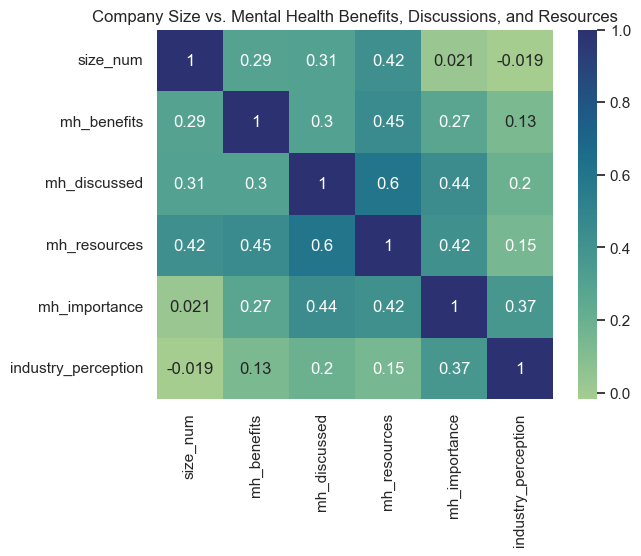

In [516]:
df_tech_dropped = df_tech.drop(columns=['UserID', 'year', 'company_size'])
sns.heatmap(df_tech_dropped.corr(), annot=True, cmap='crest')
plt.title('Company Size vs. Mental Health Benefits, Discussions, and Resources')

## 5. Final Insights
### 5.1 Suggestions for Research

### 5.2 Conclusion